# Resolver un Kakuro
Se trabajan tableros cuadrados de 3×3 a 7×7, contando las celdas de pistas.

Se usa [OpenCV](https://docs.opencv.org/5.0/tutorials/imgproc/periodic_noise_removing_filter/periodic_noise_removing_filter.html), [Tesseract](https://tesseract-ocr.github.io/tessdoc/ImproveQuality.html) y [OR-Tools](https://developers.google.com/optimization/cp/cp_solver).


In [1]:
!apt-get update -qq
!apt-get install -y tesseract-ocr -qq
%pip install -q opencv-python-headless==5.0.0.93 pytesseract==0.3.13 ortools==9.15.6755 matplotlib


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 29.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [2]:
import cv2
import numpy as np
import re
import pytesseract
from collections import Counter
from time import perf_counter
from ortools.sat.python import cp_model


##Configurar el tamaño


In [3]:
MAX_N = 7  # Mayor tamaño de tablero que se busca
LADO = 840  # Tamaño de la imagen al corregir la perspectiva

##Buscar el tablero y corregir la inclinación


In [4]:
# Ordenamos las esquinas del tablero.
def ordenar_puntos(puntos):
    puntos = np.asarray(puntos, np.float32).reshape(4, 2)
    suma = puntos.sum(axis=1)
    resta = np.diff(puntos, axis=1).ravel()
    return puntos[[np.argmin(suma), np.argmin(resta), np.argmax(suma), np.argmax(resta)]]


In [5]:
# Buscamos las líneas de la cuadrícula.
def proyecciones_lineas(imagen):
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    gris = cv2.GaussianBlur(gris, (3, 3), 0)
    bordes = cv2.Canny(gris, 20, 80)
    bordes = cv2.dilate(bordes, np.ones((3, 3), np.uint8))
    largo = max(25, imagen.shape[0] // 12)
    horizontal = cv2.morphologyEx(
        bordes, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (largo, 1))
    )
    vertical = cv2.morphologyEx(
        bordes, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, largo))
    )
    return np.mean(vertical > 0, axis=0), np.mean(horizontal > 0, axis=1)


In [6]:
# Vemos cuántas filas y columnas tiene el tablero.
def detectar_cuadricula(imagen):
    px, py = proyecciones_lineas(imagen)
    candidatos = []
    for n in range(3, MAX_N + 1):
        valores, lineas = [], []
        for perfil in (px, py):
            posiciones = [0]
            for k in range(1, n):
                centro = k * (len(perfil) - 1) / n
                radio = max(4, round(len(perfil) / n * 0.09))
                a, b = round(centro) - radio, round(centro) + radio + 1
                posicion = a + int(np.argmax(perfil[a:b]))
                posiciones.append(posicion)
                valores.append(float(perfil[posicion]))
            posiciones.append(len(perfil) - 1)
            lineas.append(posiciones)
        puntaje = np.mean(valores) + 0.2 * min(valores) + 0.015 * n
        candidatos.append((puntaje, min(valores), n, lineas))
    puntaje, minimo, n, lineas = max(candidatos, key=lambda x: x[0])
    if minimo < 0.10 or puntaje < 0.32:
        raise ValueError("No se encontró una cuadrícula regular suficientemente clara.")
    return n, lineas[0], lineas[1], float(puntaje)


In [7]:
# Si el contorno falla, buscamos los bordes con líneas.
def candidatos_por_lineas(gris):
    """Busca las esquinas a partir de líneas largas."""
    h, w = gris.shape
    lista = []
    for sigma in (2, 5):
        suave = cv2.GaussianBlur(gris, (0, 0), sigma)
        bordes = cv2.Canny(suave, 4, 16)
        detectadas = cv2.HoughLinesP(
            bordes, 1, np.pi / 720, threshold=45, minLineLength=min(h, w) * 0.25, maxLineGap=30
        )
        if detectadas is not None:
            lista.extend(detectadas.reshape(-1, 4))
    segmentos = np.array(lista) if lista else None
    if segmentos is None:
        return []
    familias = [[], []]
    for x1, y1, x2, y2 in segmentos.reshape(-1, 4):
        dx, dy = x2 - x1, y2 - y1
        largo = np.hypot(dx, dy)
        if abs(dy) < 0.45 * abs(dx):
            tipo = 0
        elif abs(dx) < 0.45 * abs(dy):
            tipo = 1
        else:
            continue
        linea = np.array([y1 - y2, x2 - x1, x1 * y2 - x2 * y1], float) / largo
        if linea[tipo ^ 1] < 0:
            linea = -linea
        centro = (
            -(linea[0] * w / 2 + linea[2]) / linea[1]
            if tipo == 0
            else -(linea[1] * h / 2 + linea[2]) / linea[0]
        )
        familias[tipo].append((largo, centro, linea))
    grupos = []
    for familia in familias:
        unicas = []
        for largo, centro, linea in sorted(familia, key=lambda t: t[0], reverse=True):
            if not any(
                abs(centro - c) < 12 and np.linalg.norm(linea[:2] - l[:2]) < 0.08
                for _, c, l in unicas
            ):
                unicas.append((largo, centro, linea))
        grupos.append(unicas[:30])

    def interseccion(a, b):
        p = np.cross(a, b)
        return p[:2] / p[2] if abs(p[2]) > 1e-6 else np.array([-1e6, -1e6])

    parejas = []
    for tipo, familia in enumerate(grupos):
        parejas.append(
            [
                (a, b)
                for i, a in enumerate(familia)
                for b in familia[i + 1 :]
                if abs(a[1] - b[1]) > 0.45 * (h if tipo == 0 else w)
            ]
        )
    candidatos = []
    for ha, hb in parejas[0]:
        for va, vb in parejas[1]:
            q = ordenar_puntos(
                [
                    interseccion(ha[2], va[2]),
                    interseccion(ha[2], vb[2]),
                    interseccion(hb[2], va[2]),
                    interseccion(hb[2], vb[2]),
                ]
            )
            area = cv2.contourArea(q)
            if (
                0.15 * h * w < area < 0.95 * h * w
                and np.all(q >= 0)
                and np.all(q[:, 0] < w)
                and np.all(q[:, 1] < h)
            ):
                soporte = sum(t[0] for t in (ha, hb, va, vb))
                candidatos.append((soporte, area, q))
    return [(area, q) for _, area, q in sorted(candidatos, key=lambda t: t[1], reverse=True)[:250]]


In [8]:
# Buscamos el tablero completo y corregimos la perspectiva.
def rectificar_tablero(imagen):
    alto, ancho = imagen.shape[:2]
    escala = min(1, 1100 / max(alto, ancho))
    pequena = cv2.resize(imagen, None, fx=escala, fy=escala) if escala < 1 else imagen
    gris = cv2.cvtColor(pequena, cv2.COLOR_BGR2GRAY)
    gris = cv2.GaussianBlur(gris, (5, 5), 0)
    realzada = cv2.createCLAHE(clipLimit=2, tileGridSize=(8, 8)).apply(gris)
    mapas = [
        cv2.Canny(gris, 25, 85),
        cv2.Canny(realzada, 35, 100),
        cv2.adaptiveThreshold(
            gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 8
        ),
    ]
    cuadrilateros = []
    area_imagen = pequena.shape[0] * pequena.shape[1]
    for mapa in mapas:
        mapa = cv2.morphologyEx(mapa, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
        contornos, _ = cv2.findContours(mapa, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        for contorno in contornos:
            area = cv2.contourArea(contorno)
            if not 0.06 * area_imagen < area < 0.99 * area_imagen:
                continue
            perimetro = cv2.arcLength(contorno, True)
            for epsilon in (0.015, 0.025, 0.04):
                poligono = cv2.approxPolyDP(contorno, epsilon * perimetro, True)
                if len(poligono) == 4 and cv2.isContourConvex(poligono):
                    q = ordenar_puntos(poligono)
                    lados = np.linalg.norm(q - np.roll(q, 1, axis=0), axis=1)
                    if min(lados) / max(lados) < 0.25:
                        continue
                    if not any(
                        np.mean(np.linalg.norm(q - q0, axis=1)) < 6 for _, q0 in cuadrilateros
                    ):
                        cuadrilateros.append((area, q))
                    break
    cuadrilateros.sort(key=lambda x: x[0], reverse=True)
    destino = np.float32([[0, 0], [LADO - 1, 0], [LADO - 1, LADO - 1], [0, LADO - 1]])
    mejores = []
    for area, q in cuadrilateros[:24]:
        matriz = cv2.getPerspectiveTransform(q / escala, destino)
        rectificada = cv2.warpPerspective(imagen, matriz, (LADO, LADO))
        try:
            n, lx, ly, puntaje = detectar_cuadricula(rectificada)
            mejores.append((puntaje, area, rectificada, n, lx, ly))
        except ValueError:
            pass
    if not mejores:
        for area, q in candidatos_por_lineas(gris):
            matriz = cv2.getPerspectiveTransform(q / escala, destino)
            rectificada = cv2.warpPerspective(imagen, matriz, (LADO, LADO))
            try:
                n, lx, ly, puntaje = detectar_cuadricula(rectificada)
                mejores.append((puntaje, area, rectificada, n, lx, ly))
            except ValueError:
                pass
        if mejores:
            # Elegimos el tablero completo para evitar un recorte de solo una parte.
            limite = 0.8 * max(t[0] for t in mejores)
            mejores = [max((t for t in mejores if t[0] >= limite), key=lambda t: t[1])]
    if not mejores:
        raise ValueError(
            "No se pudo localizar el tablero completo. Usa una foto nítida con sus cuatro bordes visibles."
        )
    puntaje, _, rectificada, n, lx, ly = max(mejores, key=lambda x: (x[0], x[1]))
    return rectificada, n, lx, ly, puntaje


## Separar las celdas y ver cuáles son blancas


In [9]:
# Recortamos las celdas y diferenciamos las blancas de las oscuras.
def segmentar_y_clasificar(imagen, n, lx, ly):
    recortes = {
        (f + 1, c + 1): imagen[ly[f] : ly[f + 1], lx[c] : lx[c + 1]]
        for f in range(n)
        for c in range(n)
    }
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    paso = round(imagen.shape[0] / n)
    k = max(3, paso // 3)
    fondo = cv2.morphologyEx(gris, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8))
    iluminacion = cv2.dilate(fondo, np.ones((paso * 3 + 1, paso * 3 + 1), np.uint8))
    iluminacion = cv2.GaussianBlur(iluminacion, (0, 0), paso / 2)
    normalizada = cv2.divide(gris, np.maximum(iluminacion, 1), scale=255)
    valores = []
    for f in range(n):
        for c in range(n):
            region = normalizada[ly[f] : ly[f + 1], lx[c] : lx[c + 1]]
            h, w = region.shape
            valores.append(
                np.median(region[int(0.2 * h) : int(0.8 * h), int(0.2 * w) : int(0.8 * w)])
            )
    valores = np.uint8(valores).reshape(n, n)
    umbral, _ = cv2.threshold(valores, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if int(valores.max()) - int(valores.min()) < 15:
        raise ValueError("No se distinguen celdas blancas y oscuras con suficiente contraste.")
    fondos = np.zeros((n, n), np.float32)
    oscuras = set()
    for (f, c), celda in recortes.items():
        g = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
        h, w = g.shape
        fondos[f - 1, c - 1] = np.median(
            g[int(0.2 * h) : int(0.8 * h), int(0.2 * w) : int(0.8 * w)]
        )
        bordes = cv2.Canny(cv2.GaussianBlur(g, (5, 5), 0), 35, 110)
        lineas = cv2.HoughLinesP(
            bordes,
            1,
            np.pi / 180,
            threshold=max(12, h // 5),
            minLineLength=h * 0.65,
            maxLineGap=h * 0.08,
        )
        diagonal = False
        if lineas is not None:
            for x1, y1, x2, y2 in lineas.reshape(-1, 4):
                dx, dy = x2 - x1, y2 - y1
                if (
                    dx * dy > 0
                    and 0.8 < abs(dy / (dx or 1)) < 1.25
                    and abs((y1 + y2) / 2 - (x1 + x2) / 2) < 0.07 * h
                ):
                    diagonal = True
                    break
        if f == 1 or c == 1 or diagonal:
            oscuras.add((f, c))
    blancas = set()
    for f in range(1, n + 1):
        for c in range(1, n + 1):
            if (f, c) in oscuras:
                continue
            distancia = min(max(abs(f - a), abs(c - b)) for a, b in oscuras)
            vecinos = [
                fondos[a - 1, b - 1] for a, b in oscuras if max(abs(f - a), abs(c - b)) == distancia
            ]
            referencia = min(vecinos)
            if valores[f - 1, c - 1] > umbral or fondos[f - 1, c - 1] > referencia + max(
                8, 0.10 * referencia
            ):
                blancas.add((f, c))
    # Una celda blanca debe formar un grupo horizontal y otro vertical.
    while True:
        aisladas = {
            p
            for p in blancas
            if not any((p[0], p[1] + d) in blancas for d in (-1, 1))
            or not any((p[0] + d, p[1]) in blancas for d in (-1, 1))
        }
        if not aisladas:
            break
        blancas -= aisladas
    return blancas, recortes


##Preparar y leer las pistas


In [10]:
# Reducimos las bandas de la imagen si la primera lectura falla.
def filtrar_bandas(imagen, n):
    """Reduce las bandas con un filtro de frecuencias."""
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY).astype(np.float32)
    h, w = gris.shape
    y, x = np.mgrid[:h, :w]
    espectro = np.fft.fftshift(np.fft.fft2(gris))
    # Conservamos las frecuencias bajas y reducimos las bandas que se repiten.
    limite = max(12, 2 * n)
    bandas = [
        (np.abs(y - h // 2) <= 3) & (np.abs(x - w // 2) > limite),
        (np.abs(x - w // 2) <= 3) & (np.abs(y - h // 2) > limite),
    ]
    mascara = max(bandas, key=lambda m: np.sum(np.abs(espectro[m]) ** 2))
    espectro[mascara] *= 0.03
    filtrada = np.real(np.fft.ifft2(np.fft.ifftshift(espectro)))
    filtrada = np.uint8(np.clip(filtrada, 0, 255))
    return cv2.cvtColor(filtrada, cv2.COLOR_GRAY2BGR)


In [11]:
# Separamos el número de la diagonal y quitamos ruido pequeño.
def preparar_numero(
    celda, direccion, adaptativa=False, invertir=False, normalizar=False, constante=7
):
    gris = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    h, w = gris.shape
    if normalizar:
        # Ajustamos el fondo para reducir bandas y cambios de luz.
        fondo_local = cv2.GaussianBlur(gris, (3, (max(15, h // 2) | 1)), 0)
        gris = cv2.divide(gris, np.maximum(fondo_local, 1), scale=160)
    y, x = np.mgrid[:h, :w]
    xn, yn = x / w, y / h
    mascara = (xn > 0.035) & (xn < 0.965) & (yn > 0.035) & (yn < 0.965)
    mascara &= (yn < xn - 0.09) if direccion == "derecha" else (yn > xn + 0.09)
    mascara &= (yn < 0.52) if direccion == "derecha" else (yn > 0.48)
    fondo = float(np.median(gris[int(0.12 * h) : int(0.88 * h), int(0.12 * w) : int(0.88 * w)]))
    base = cv2.GaussianBlur(gris, (3, 3), 0)
    modo = cv2.THRESH_BINARY if fondo < 100 else cv2.THRESH_BINARY_INV
    if invertir:
        modo = cv2.THRESH_BINARY_INV if modo == cv2.THRESH_BINARY else cv2.THRESH_BINARY
    if adaptativa:
        bloque = max(15, min(51, (min(h, w) // 3) | 1))
        tinta = cv2.adaptiveThreshold(
            base,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            modo,
            bloque,
            -constante if fondo < 100 else constante,
        )
    else:
        tinta = cv2.threshold(base, 0, 255, modo + cv2.THRESH_OTSU)[1]
    tinta[~mascara] = 0
    cantidad, etiquetas, estadisticas, _ = cv2.connectedComponentsWithStats(tinta)
    componentes = []
    for i in range(1, cantidad):
        cx, cy, cw, ch, area = estadisticas[i]
        if 0.085 * h <= ch <= 0.48 * h and 0.008 * w <= cw <= 0.38 * w and area >= h * w * 0.0008:
            componentes.append((i, cx, cy, cw, ch, area))
    if not componentes:
        return None
    # Quitamos manchas pequeñas comparadas con los números.
    altura = max(c[4] for c in componentes)
    componentes = [c for c in componentes if c[4] >= 0.55 * altura]
    seleccion = np.isin(etiquetas, [c[0] for c in componentes])
    ys, xs = np.where(seleccion)
    numero = (255 - 255 * seleccion.astype(np.uint8))[
        ys.min() : ys.max() + 1, xs.min() : xs.max() + 1
    ]
    factor = 64 / numero.shape[0]
    numero = cv2.resize(numero, None, fx=factor, fy=factor, interpolation=cv2.INTER_CUBIC)
    return cv2.copyMakeBorder(numero, 16, 16, 16, 16, cv2.BORDER_CONSTANT, value=255)


In [12]:
# Leemos la pista con Tesseract y guardamos las opciones.
def leer_pista(celda, direccion, reforzado=False):
    votos, confianza = Counter(), {}
    if reforzado:
        # Después del filtro, probamos tres umbrales para leer las pistas.
        intentos = [(False, True, inv, c) for c in (7, 14, 21) for inv in (False, True)]
    else:
        intentos = [
            (norm, ad, inv, 7)
            for norm, ad, inv in (
                (False, False, False),
                (False, False, True),
                (False, True, False),
                (False, True, True),
                (True, False, False),
                (True, False, True),
                (True, True, False),
                (True, True, True),
            )
        ]
    for normalizar, adaptativa, invertir, constante in intentos:
        numero = preparar_numero(celda, direccion, adaptativa, invertir, normalizar, constante)
        if numero is None:
            continue
        _, _, componentes, _ = cv2.connectedComponentsWithStats(np.uint8(numero < 128))
        dos_digitos = sum(ch >= 35 and area >= 35 for _, _, cw, ch, area in componentes[1:]) == 2
        for psm in (7, 8, 13):
            datos = pytesseract.image_to_data(
                numero,
                output_type=pytesseract.Output.DICT,
                config=f"--oem 1 --psm {psm} -c tessedit_char_whitelist=0123456789",
                timeout=5,
            )
            indices = [i for i, t in enumerate(datos["text"]) if str(t).strip()]
            texto = "".join(str(datos["text"][i]).strip() for i in indices)
            if re.fullmatch(r"\d{1,2}", texto) and 1 <= int(texto) <= 45:
                valor = int(texto)
                votos[valor] += 3 if dos_digitos and len(texto) == 2 else 1
                conf = max([float(datos["conf"][i]) for i in indices], default=0)
                confianza[valor] = max(confianza.get(valor, 0), conf)
        if (
            not reforzado
            and votos
            and votos.most_common(1)[0][1] >= 2
            and (normalizar or max(confianza.values()) >= 35)
        ):
            break
    return sorted(votos, key=lambda v: (votos[v], confianza[v]), reverse=True)[:4]


In [13]:
# Leemos la pista si tiene celdas blancas a la derecha o abajo.
def extraer_pistas(recortes, blancas, n, reforzado=False):
    pistas = {}
    for (f, c), celda in recortes.items():
        if (f, c) in blancas:
            continue
        lecturas = {}
        if (f, c + 1) in blancas:
            lecturas["derecha"] = leer_pista(celda, "derecha", reforzado)
        if (f + 1, c) in blancas:
            lecturas["abajo"] = leer_pista(celda, "abajo", reforzado)
        if lecturas:
            pistas[(f, c)] = lecturas
    return pistas


## Formar los grupos de celdas


In [14]:
# Formamos los grupos y revisamos que cada celda esté en ambos sentidos.
def construir_grupos(blancas, pistas, n):
    if not blancas:
        raise ValueError(
            "No se detectaron celdas blancas; revisa la iluminación y el recorte del tablero."
        )
    grupos = []
    for origen, lecturas in pistas.items():
        for direccion, candidatos in lecturas.items():
            df, dc = (0, 1) if direccion == "derecha" else (1, 0)
            f, c = origen[0] + df, origen[1] + dc
            celdas = []
            while (f, c) in blancas:
                celdas.append((f, c))
                f += df
                c += dc
            if len(celdas) < 2:
                raise ValueError(f"Grupo incompleto en {origen}, {direccion}.")
            grupos.append(
                {"origen": origen, "direccion": direccion, "celdas": celdas, "ocr": candidatos}
            )
    cobertura = Counter((celda, g["direccion"]) for g in grupos for celda in g["celdas"])
    if any(cobertura[(celda, d)] != 1 for celda in blancas for d in ("derecha", "abajo")):
        raise ValueError("La segmentación no forma grupos horizontales y verticales completos.")
    return grupos


## Variables y dominios
Cada celda blanca puede tener un valor del 1 al 9.
Las sumas de los grupos se toman de los candidatos que reconoce el OCR.


In [15]:
CONFUSIONES = {
    "0": "689",
    "1": "7",
    "2": "7",
    "3": "58",
    "4": "1",
    "5": "368",
    "6": "589",
    "7": "12",
    "8": "3569",
    "9": "68",
}


In [16]:
# Guardamos las sumas posibles y el costo de cada lectura.
def dominios_pistas(grupos):
    """Calcula las sumas posibles para cada grupo."""
    dominios = []
    for g in grupos:
        L = len(g["celdas"])
        minimo, maximo = L * (L + 1) // 2, L * (19 - L) // 2
        costos = {}
        for rango, numero in enumerate(g["ocr"]):
            if minimo <= numero <= maximo:
                costos[numero] = min(costos.get(numero, 999), rango)
            # Probamos posibles confusiones de cifras con un costo mayor.
            for j, digito in enumerate(str(numero)):
                for nuevo in CONFUSIONES.get(digito, ""):
                    variante = int(str(numero)[:j] + nuevo + str(numero)[j + 1 :])
                    if minimo <= variante <= maximo:
                        costos[variante] = min(costos.get(variante, 999), 10 + rango)
        dominios.append(costos)
    return dominios


In [17]:
# Creamos una variable por celda blanca y una suma por grupo.
def crear_variables(modelo, blancas, dominios):
    # Las celdas van del 1 al 9; las sumas usan los candidatos del OCR.
    variables = {c: modelo.NewIntVar(1, 9, f"x_{c[0]}_{c[1]}") for c in sorted(blancas)}
    sumas = [
        modelo.NewIntVarFromDomain(cp_model.Domain.FromValues(sorted(d)), f"s_{i}")
        for i, d in enumerate(dominios)
    ]
    return variables, sumas


## Restricciones
En cada grupo, los números deben sumar la pista y no repetirse.


In [18]:
# Agregamos las restricciones de cada grupo.
def agregar_restricciones(modelo, variables, sumas, grupos):
    # Los valores deben sumar la pista y ser diferentes entre sí.
    for g, s in zip(grupos, sumas):
        valores = [variables[c] for c in g["celdas"]]
        modelo.Add(sum(valores) == s)
        modelo.AddAllDifferent(valores)


## Objetivo
Se da un costo a cada lectura del OCR. El modelo busca la combinación compatible con las restricciones que tenga menor costo total.


In [19]:
# Elegimos las lecturas compatibles con menor costo.
def definir_objetivo(modelo, sumas, dominios):
    # El booleano indica si se usa esa suma y permite contar su costo.
    penalizaciones = []
    for i, (s, costos) in enumerate(zip(sumas, dominios)):
        for valor, costo in costos.items():
            elegido = modelo.NewBoolVar(f"b_{i}_{valor}")
            modelo.Add(s == valor).OnlyEnforceIf(elegido)
            modelo.Add(s != valor).OnlyEnforceIf(elegido.Not())
            penalizaciones.append(costo * elegido)
    modelo.Minimize(sum(penalizaciones))


## Resolver con CP


In [20]:
# Creamos el modelo, lo resolvemos y medimos el tiempo.
def resolver_csp(blancas, grupos):
    inicio = perf_counter()
    if any(not g["ocr"] for g in grupos):
        return (
            None,
            None,
            {"estado": "PISTAS_SIN_LECTURA", "tiempo_solver_s": None, "tiempo_modelo_s": 0},
        )
    dominios = dominios_pistas(grupos)
    if any(not d for d in dominios):
        return (
            None,
            None,
            {
                "estado": "PISTAS_FUERA_DE_RANGO",
                "tiempo_solver_s": None,
                "tiempo_modelo_s": perf_counter() - inicio,
            },
        )
    modelo = cp_model.CpModel()
    variables, sumas = crear_variables(modelo, blancas, dominios)
    agregar_restricciones(modelo, variables, sumas, grupos)
    definir_objetivo(modelo, sumas, dominios)
    tiempo_modelo = perf_counter() - inicio
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 15
    solver.parameters.num_search_workers = 1
    solver.parameters.random_seed = 0
    estado = solver.Solve(modelo)
    estadisticas = {
        "estado": solver.StatusName(estado),
        "tiempo_modelo_s": tiempo_modelo,
        "tiempo_solver_s": solver.WallTime(),
        "ramas": solver.NumBranches(),
        "conflictos": solver.NumConflicts(),
    }
    if estado not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None, None, estadisticas
    estadisticas["penalizacion"] = solver.ObjectiveValue()
    return (
        {c: solver.Value(v) for c, v in variables.items()},
        [solver.Value(s) for s in sumas],
        estadisticas,
    )


In [21]:
# Extraemos las pistas de la imagen y las pasamos al modelo.
def procesar_imagen(imagen):
    inicio = perf_counter()
    resultado = {"estado": "NO_EJECUTADO", "solucion": None, "vision_ok": False}
    etapa = "tablero"
    try:
        if imagen is None:
            raise ValueError("No se pudo leer la imagen.")
        rectificada, n, lx, ly, puntaje = rectificar_tablero(imagen)
        resultado.update(imagen=rectificada, n=n, lx=lx, ly=ly, puntaje_cuadricula=puntaje)
        etapa = "clasificacion"
        blancas, recortes = segmentar_y_clasificar(rectificada, n, lx, ly)
        etapa = "ocr"
        pistas = extraer_pistas(recortes, blancas, n)
        resultado.update(
            blancas=blancas, pistas=pistas, vision_ok=True, tiempo_vision_s=perf_counter() - inicio
        )
        etapa = "grupos"
        grupos = construir_grupos(blancas, pistas, n)
        resultado["grupos"] = grupos
        etapa = "solver"
        solucion, sumas, estadisticas = resolver_csp(blancas, grupos)
        resultado.update(
            estadisticas,
            solucion=solucion,
            sumas=sumas,
            busquedas_cp=int(estadisticas.get("tiempo_solver_s") is not None),
        )
        if solucion is None:
            etapa = "relectura"
            inicio_extra = perf_counter()
            filtrada = filtrar_bandas(rectificada, n)
            recortes_extra = {
                (f + 1, c + 1): filtrada[ly[f] : ly[f + 1], lx[c] : lx[c + 1]]
                for f in range(n)
                for c in range(n)
            }
            pistas_extra = extraer_pistas(recortes_extra, blancas, n, reforzado=True)
            resultado["tiempo_vision_s"] += perf_counter() - inicio_extra
            grupos_extra = construir_grupos(blancas, pistas_extra, n)
            solucion_extra, sumas_extra, stats_extra = resolver_csp(blancas, grupos_extra)
            resultado.update(
                reintento_bandas=True,
                estado_inicial=resultado["estado"],
                estado_reintento=stats_extra["estado"],
            )
            resultado["busquedas_cp"] += int(stats_extra.get("tiempo_solver_s") is not None)
            # Sumamos los tiempos de los intentos realizados.
            for clave in ("tiempo_modelo_s", "ramas", "conflictos"):
                resultado[clave] = (resultado.get(clave) or 0) + (stats_extra.get(clave) or 0)
            tiempos = [
                t
                for t in (resultado.get("tiempo_solver_s"), stats_extra.get("tiempo_solver_s"))
                if t is not None
            ]
            resultado["tiempo_solver_s"] = sum(tiempos) if tiempos else None
            if solucion_extra is not None:
                solucion, sumas, grupos = solucion_extra, sumas_extra, grupos_extra
                resultado.update(
                    estado=stats_extra["estado"],
                    solucion=solucion,
                    sumas=sumas,
                    grupos=grupos,
                    pistas=pistas_extra,
                    imagen=filtrada,
                    penalizacion=stats_extra.get("penalizacion"),
                )
        if solucion is not None:
            resultado["ajustes"] = [
                (g["origen"], g["direccion"], g["ocr"], s)
                for g, s in zip(grupos, sumas)
                if s != g["ocr"][0]
            ]
    except Exception as error:
        resultado.update(error=str(error), error_etapa=etapa)
    resultado.setdefault("tiempo_vision_s", perf_counter() - inicio)
    resultado["tiempo_total_s"] = perf_counter() - inicio
    return resultado


## Dar la solución en la imagen


In [22]:
# Escribimos la solución en las celdas blancas.
def dibujar_solucion(resultado):
    imagen = resultado["imagen"].copy()
    lx, ly = resultado["lx"], resultado["ly"]
    for (f, c), valor in (resultado["solucion"] or {}).items():
        texto = str(valor)
        paso = min(lx[c] - lx[c - 1], ly[f] - ly[f - 1])
        escala = paso / 110
        (w, h), _ = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, escala, 2)
        x = (lx[c - 1] + lx[c] - w) // 2
        y = (ly[f - 1] + ly[f] + h) // 2
        cv2.putText(
            imagen, texto, (x, y), cv2.FONT_HERSHEY_SIMPLEX, escala, (0, 0, 0), 2, cv2.LINE_AA
        )
    return imagen


## Escoger una imagen


In [23]:
from google.colab import files

archivos = files.upload()
if len(archivos) != 1:
    raise ValueError("Selecciona una sola imagen PNG o JPG.")
nombre, contenido = next(iter(archivos.items()))
imagen = cv2.imdecode(np.frombuffer(contenido, np.uint8), cv2.IMREAD_COLOR)
if imagen is None:
    raise ValueError("El archivo no es una imagen válida.")
print("Imagen seleccionada:", nombre)


Saving KC_kakuro_05x05_facil_moiré.png to KC_kakuro_05x05_facil_moiré.png
Imagen seleccionada: KC_kakuro_05x05_facil_moiré.png


In [24]:
resultado = procesar_imagen(imagen)
print("Estado del modelo:", resultado["estado"])
print(f"Tiempo total: {resultado['tiempo_total_s']:.3f} s")
if resultado.get("tiempo_solver_s") is not None:
    print(f"Tiempo del solver: {resultado['tiempo_solver_s']:.4f} s")

if resultado.get("reintento_bandas"):
    print("Se aplicó un filtro de bandas y se volvieron a leer las pistas.")
if resultado.get("error"):
    print("Problema:", resultado["error"])

# Mostramos las pistas que el modelo cambió respecto a la primera lectura.
if resultado.get("ajustes"):
    print("Pistas ajustadas (celda, dirección, lectura → suma usada):")
    for celda, direccion, candidatos, suma in resultado["ajustes"]:
        print(f"{celda}, {direccion}: {candidatos[0]} → {suma}")

if resultado["estado"] in {"PISTAS_SIN_LECTURA", "PISTAS_FUERA_DE_RANGO"}:
    print("No se leyeron bien algunas pistas. Prueba con una imagen más clara.")
elif resultado["estado"] == "INFEASIBLE":
    print("Las pistas leídas no permiten una solución con las reglas de Kakuro.")


Estado del modelo: OPTIMAL
Tiempo total: 34.832 s
Tiempo del solver: 0.0302 s
Se aplicó un filtro de bandas y se volvieron a leer las pistas.
Pistas ajustadas (celda, dirección, lectura → suma usada):
(3, 1), derecha: 13 → 18


## Mostrar el resultado


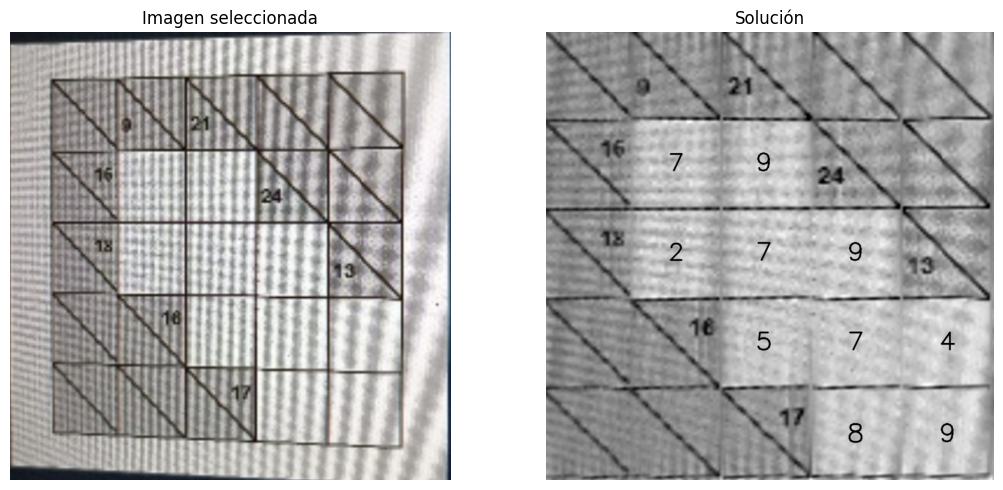

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen seleccionada")
if "imagen" in resultado:
    vista = dibujar_solucion(resultado)
    axes[1].imshow(cv2.cvtColor(vista, cv2.COLOR_BGR2RGB))
    titulo = (
        "Solución" if resultado["solucion"] is not None else "Sin solución: tablero rectificado"
    )
    axes[1].set_title(titulo)
else:
    axes[1].set_title("Tablero no detectado")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
